# Over- and Under-Provisioning Figure Generator

Generates PGFPlots `\addplot` statements for two figures:
1. **Over-provisioning** (SeqRd): cost and execution time vs. memory — cost rises while time stays flat.
2. **Under-provisioning** (Comp): execution time and speedup vs. memory — dramatic performance gain from proper provisioning.

**Provider**: AWS Lambda, warm invocations only.
**Pricing**: $0.0000166667 per GB-second + $0.0000002 per request.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df_aws = pd.read_csv('aws_warm_aggregated.csv')
df_gcp = pd.read_csv('gcp_warm_aggregated.csv')

# AWS Lambda pricing
AWS_PRICE_PER_GB_SECOND = 0.0000166667
AWS_PRICE_PER_REQUEST   = 0.0000002

# GCP Cloud Functions pricing
GCP_PRICE_PER_GB_SECOND = 0.0000100
GCP_PRICE_PER_REQUEST   = 0.0000004

df_aws['cost_per_1T'] = (
    (df_aws['total_time_ms'] / 1000) * (df_aws['memory_mb'] / 1024) * AWS_PRICE_PER_GB_SECOND
    + AWS_PRICE_PER_REQUEST
) * 1e3

df_gcp['cost_per_1T'] = (
    (df_gcp['total_time_ms'] / 1000) * (df_gcp['memory_mb'] / 1024) * GCP_PRICE_PER_GB_SECOND
    + GCP_PRICE_PER_REQUEST
) * 1e3

# Task to archetype label mapping
task_map = {
    'a_passthrough':    'Pass',
    'b_compress':       'Comp',
    'c_decompress':     'Decomp',
    'e_matrix_multiply':'MatMul',
    'g_reduce':         'Aggr',
    'h_expand':         'Expand',
    'k_latency_bound':  'SeqRd',
    'f_matrix_to_csv':  'f_matrix_to_csv',
    'd_csv_to_matrix':  'd_csv_to_matrix',
}
df_aws['archetype'] = df_aws['task'].map(task_map)
df_gcp['archetype'] = df_gcp['task'].map(task_map)

warm_aws = df_aws[df_aws['cold_start'] == False].copy()
warm_gcp = df_gcp[df_gcp['cold_start'] == False].copy()

print('Data loaded.')
print('AWS archetypes:', warm_aws['archetype'].dropna().unique())
print('GCP archetypes:', warm_gcp['archetype'].dropna().unique())


## Figure 1: Over-Provisioning (SeqRd, medium payload)

SeqRd runtime is dominated by storage round-trip latency and stays flat across memory.
Cost increases linearly — a direct manifestation of over-provisioning.
Dual y-axis: left = cost per 1T, right = execution time (s).

In [ ]:
seqrd = (
    warm_aws[(warm_aws['archetype']=='SeqRd') & (warm_aws['payload_size']=='medium')]
    .groupby('memory_mb')
    .agg(cost=('cost_per_1T','median'), time_s=('total_time_ms', lambda x: x.median()/1000))
    .reset_index()
)

print('SeqRd at medium payload (AWS):')
print(seqrd.round(2))
print()

coords_cost = ' '.join(f'({int(r.memory_mb)},{r.cost:.2f})' for _,r in seqrd.iterrows())
coords_time = ' '.join(f'({int(r.memory_mb)},{r.time_s:.1f})' for _,r in seqrd.iterrows())

print('% ---- Over-provisioning \\addplot statements (AWS, SeqRd, medium payload) ----')
print('% Left y-axis: cost per 1T ($)')
print(f'\\addplot coordinates {{{coords_cost}}};')
print('\\addlegendentry{Cost}')
print()
print('% Right y-axis: execution time (s)')
print(f'\\addplot coordinates {{{coords_time}}};')
print('\\addlegendentry{Time}')
print()

# Preview
fig, ax1 = plt.subplots(figsize=(6,3))
ax2 = ax1.twinx()
ax1.plot(seqrd['memory_mb'], seqrd['cost'], marker='o', color='tab:blue', label='Cost')
ax2.plot(seqrd['memory_mb'], seqrd['time_s'], marker='s', color='tab:orange', linestyle='--', label='Time')
ax1.set_xlabel('Memory allocation (MB)')
ax1.set_ylabel('Cost ($ per 1T invocations)', color='tab:blue')
ax2.set_ylabel('Execution time (s)', color='tab:orange')
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.5)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
plt.title('SeqRd: Over-provisioning (AWS, medium payload)')
plt.tight_layout()
plt.savefig('overprovisioning_preview.pdf')
plt.show()
print('Saved: overprovisioning_preview.pdf')


In [ ]:
print(r"""
\begin{figure}[t]
\centering
\caption{Cost per 1000 invocations and execution time vs.\ memory allocation
         for \archetype{SeqRd} at medium payload (AWS). Execution time remains
         constant across all memory configurations, while cost increases
         monotonically, illustrating that over-provisioning raises cost
         without any performance benefit.}
\label{fig:overprovisioning}
\begin{tikzpicture}
  \begin{axis}[
    width=\columnwidth, height=4cm,
    axis y line*=left,
    xlabel={Memory allocation (MB)},
    ylabel={Cost (\$ per 1T invocations)},
    ylabel near ticks, xlabel near ticks,
    xtick={256,512,768,1024,1536,2048},
    legend style={at={(0.05,0.95)}, anchor=north west},
    label style={font=\footnotesize},
    tick label style={font=\footnotesize},
  ]
  % INSERT COST \addplot HERE
  \end{axis}
  \begin{axis}[
    width=\columnwidth, height=4cm,
    axis y line*=right, axis x line=none,
    ylabel={Execution time (s)},
    ylabel near ticks,
    xtick={256,512,768,1024,1536,2048},
    label style={font=\footnotesize},
    tick label style={font=\footnotesize},
  ]
  % INSERT TIME \addplot HERE
  \end{axis}
\end{tikzpicture}
\end{figure}
""")


## Figure 2: Under-Provisioning (MatMul, GCP, multiple payloads)

Shows execution time vs. memory for MatMul on GCP across small, medium, and large payloads.
Missing data points represent execution failures due to under-provisioning.
The staircase of starting points illustrates how larger payloads require more memory to succeed:
- small: fails at 128MB
- medium: fails at 128MB and 256MB
- large: fails at everything below 1536MB

MatMul GCP — execution time by payload and memory:
payload_size    large   medium  micro   small
memory_mb                                    
128               NaN      NaN  164.0     NaN
256               NaN      NaN  178.0  2316.0
512               NaN  11022.0  172.0  1345.0
768               NaN   6534.0  167.0   747.0
1024              NaN   7117.0  172.0   877.0
1536          28313.0   3910.0  167.0   525.0
2048          26730.0   4097.0  159.0   534.0

% ---- Under-provisioning \addplot statements (GCP, MatMul) ----
% Missing configurations = execution failures (under-provisioning)

% micro payload
\addplot coordinates {(128,164) (256,178) (512,172) (768,167) (1024,172) (1536,167) (2048,159)};
\addlegendentry{Micro}

% small payload
\addplot coordinates {(256,2316) (512,1345) (768,747) (1024,877) (1536,525) (2048,534)};
\addlegendentry{Small}

% medium payload
\addplot coordinates {(512,11022) (768,6534) (1024,7117) (1536,3910) (2048,4097)};
\addlegendentry{Medium}

% large pa

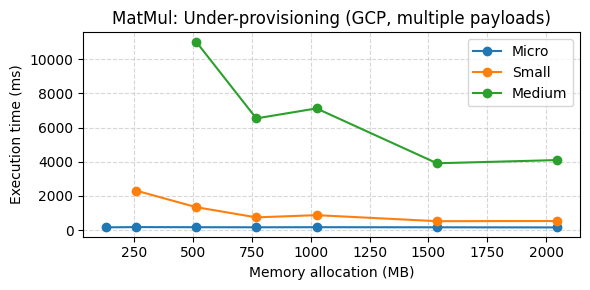

Saved: underprovisioning_preview.pdf


In [40]:
# Under-provisioning: MatMul on GCP, multiple payload sizes
# Missing configs = execution failures due to under-provisioning

matmul_gcp = warm_gcp[warm_gcp['archetype'] == 'MatMul'].copy()

payloads = ['micro', 'small', 'medium', 'large']
grp = (
    matmul_gcp[matmul_gcp['payload_size'].isin(payloads)]
    .groupby(['payload_size', 'memory_mb'])['total_time_ms']
    .median()
    .reset_index()
)

print('MatMul GCP — execution time by payload and memory:')
print(grp.pivot(index='memory_mb', columns='payload_size', values='total_time_ms').round(0).to_string())
print()

print('% ---- Under-provisioning \\addplot statements (GCP, MatMul) ----')
print('% Missing configurations = execution failures (under-provisioning)\n')
for payload in payloads:
    sub = grp[grp['payload_size']==payload].sort_values('memory_mb')
    coords = ' '.join(f'({int(r.memory_mb)},{r.total_time_ms:.0f})' for _,r in sub.iterrows())
    print(f'% {payload} payload')
    print(f'\\addplot coordinates {{{coords}}};')
    print(f'\\addlegendentry{{{payload.capitalize()}}}')
    print()

# Preview
colors = ['tab:blue', 'tab:orange', 'tab:green']
fig, ax = plt.subplots(figsize=(6,3))
for payload, color in zip(payloads, colors):
    sub = grp[grp['payload_size']==payload].sort_values('memory_mb')
    ax.plot(sub['memory_mb'], sub['total_time_ms'], marker='o', color=color, label=payload.capitalize())

ax.set_xlabel('Memory allocation (MB)')
ax.set_ylabel('Execution time (ms)')
ax.set_title('MatMul: Under-provisioning (GCP, multiple payloads)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('underprovisioning_preview.pdf')
plt.show()
print('Saved: underprovisioning_preview.pdf')


In [41]:
print(r"""
\begin{figure}[t]
\centering
\caption{Execution time vs.\ memory allocation for \archetype{MatMul} on GCP
         across small, medium, and large payloads. Missing configurations
         represent execution failures due to under-provisioning: small payload
         fails at \SI{128}{\mega\byte}, medium at \SI{128}{} and \SI{256}{\mega\byte},
         and large payload requires at least \SI{1536}{\mega\byte} to complete.}
\label{fig:underprovisioning}
\begin{tikzpicture}
  \begin{axis}[
    width=\columnwidth, height=4cm,
    xlabel={Memory allocation (MB)},
    ylabel={Execution time (ms)},
    ylabel near ticks, xlabel near ticks,
    xtick={128,256,512,768,1024,1536,2048},
    legend style={at={(0.95,0.95)}, anchor=north east},
    label style={font=\footnotesize},
    tick label style={font=\footnotesize},
  ]
  % INSERT \addplot STATEMENTS HERE
  \end{axis}
\end{tikzpicture}
\end{figure}
""")



\begin{figure}[t]
\centering
\caption{Execution time vs.\ memory allocation for \archetype{MatMul} on GCP
         across small, medium, and large payloads. Missing configurations
         represent execution failures due to under-provisioning: small payload
         fails at \SI{128}{\mega\byte}, medium at \SI{128}{} and \SI{256}{\mega\byte},
         and large payload requires at least \SI{1536}{\mega\byte} to complete.}
\label{fig:underprovisioning}
\begin{tikzpicture}
  \begin{axis}[
    width=\columnwidth, height=4cm,
    xlabel={Memory allocation (MB)},
    ylabel={Execution time (ms)},
    ylabel near ticks, xlabel near ticks,
    xtick={128,256,512,768,1024,1536,2048},
    legend style={at={(0.95,0.95)}, anchor=north east},
    label style={font=\footnotesize},
    tick label style={font=\footnotesize},
  ]
  % INSERT \addplot STATEMENTS HERE
  \end{axis}
\end{tikzpicture}
\end{figure}

